# Eliptik Eğri Kriptografisi (ECC)
## Sıfırdan Simülasyon — Kriptografi Kütüphanesi Kullanılmadan

Bu notebook ECC'nin nasıl çalıştığını adım adım gösterir:
1. Eliptik eğri nedir?
2. Nokta toplama ve katlama
3. Sonlu alan üzerinde ECC (gerçek kriptografi)
4. Anahtar üretimi
5. ECDH — Anahtar Değişimi
6. ECDSA — Dijital İmza

---
## 1. Eliptik Eğri Nedir?

Genel form: **y² = x³ + ax + b**

Bitcoin / secp256k1 eğrisi: **y² = x³ + 7** (a=0, b=7)

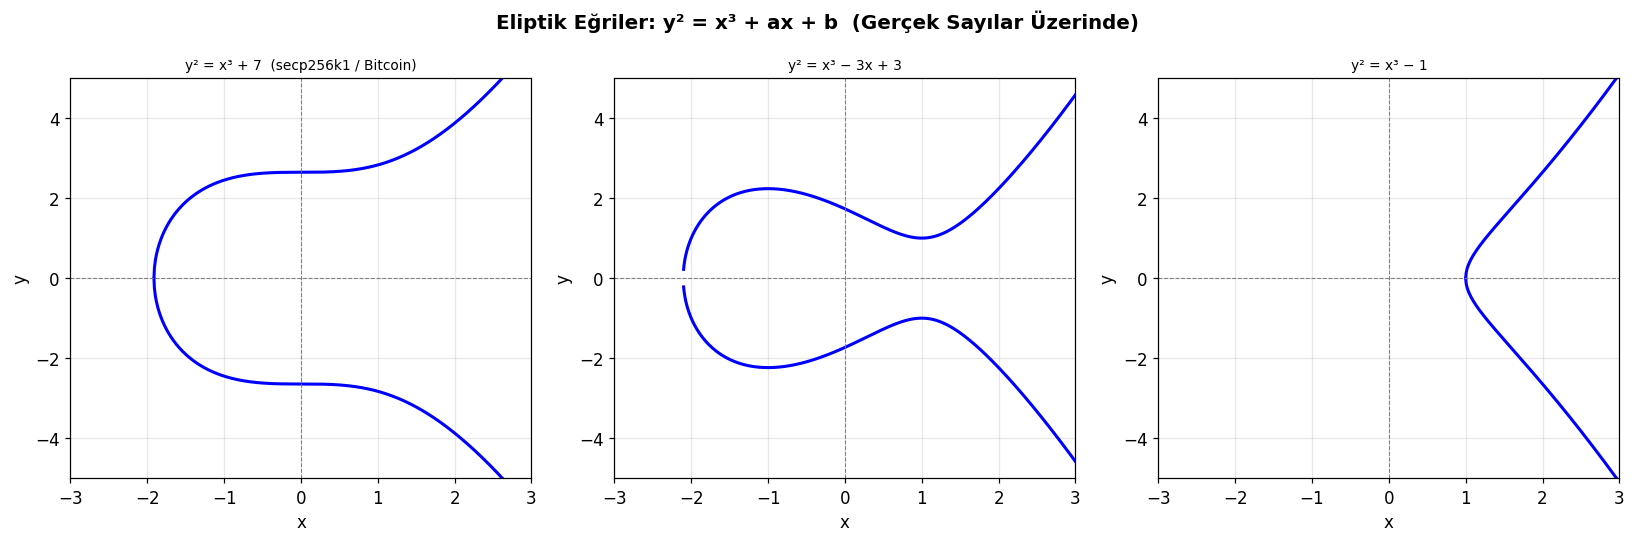

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import hashlib
import random

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

# --- Gerçek sayılar üzerinde eliptik eğri çizimi ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

curves = [
    (0, 7,   'y² = x³ + 7  (secp256k1 / Bitcoin)'),
    (-3, 3,  'y² = x³ − 3x + 3'),
    (0, -1,  'y² = x³ − 1'),
]

for ax, (a, b, title) in zip(axes, curves):
    x = np.linspace(-3, 3, 1000)
    y_sq = x**3 + a*x + b
    mask = y_sq >= 0
    x_valid = x[mask]
    y_pos =  np.sqrt(y_sq[mask])
    y_neg = -np.sqrt(y_sq[mask])

    ax.plot(x_valid, y_pos, 'b-', linewidth=2)
    ax.plot(x_valid, y_neg, 'b-', linewidth=2)
    ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.7, linestyle='--')
    ax.set_title(title, fontsize=9)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-5, 5)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

fig.suptitle('Eliptik Eğriler: y² = x³ + ax + b  (Gerçek Sayılar Üzerinde)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Nokta Toplama — Geometrik Anlam

ECC'nin temeli **nokta toplama** işlemidir:
- P + Q = R (eğriden geçen doğru, 3. noktayı keser, x eksenine göre yansıtılır)
- P + P = 2P (teğet doğrusu kullanılır)

**Formüller (gerçek sayılar):**
```
λ = (y₂ - y₁) / (x₂ - x₁)        # P ≠ Q
λ = (3x₁² + a) / (2y₁)            # P = Q (katlama)

x₃ = λ² - x₁ - x₂
y₃ = λ(x₁ - x₃) - y₁
```

P = (-1.500, 1.904)
Q = (2.000, 3.873)
R = P + Q = (-0.184, -2.645)


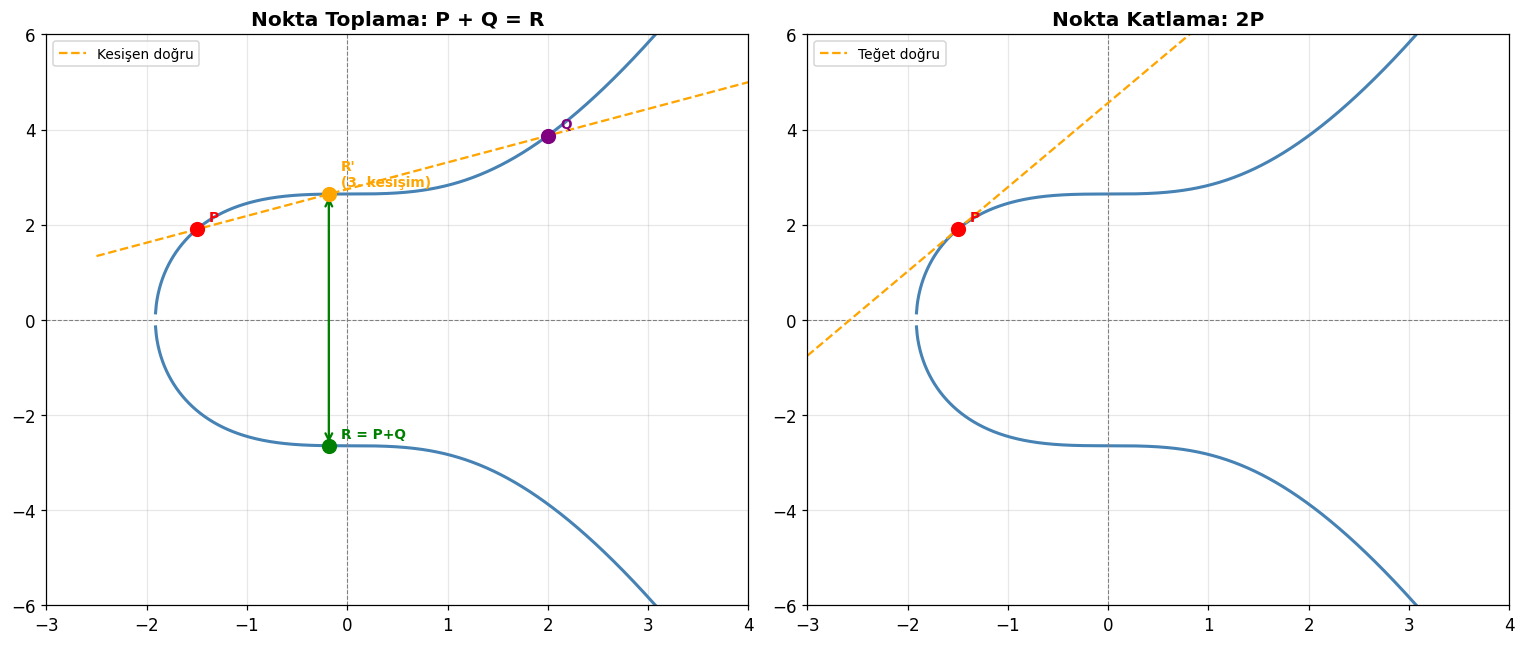


Not: Yansıma işlemi (R' → R): x eksenine göre simetri alınır, yani y işareti değiştirilir.


In [4]:
# Gerçek sayılar üzerinde ECC sınıfı (görselleştirme için)
class EllipticCurveReal:
    def __init__(self, a, b):
        self.a = a
        self.b = b

    def is_on_curve(self, x, y, tol=1e-6):
        return abs(y**2 - (x**3 + self.a*x + self.b)) < tol

    def add(self, P, Q):
        """P + Q -> R"""
        if P is None: return Q
        if Q is None: return P
        x1, y1 = P
        x2, y2 = Q
        if abs(x1 - x2) < 1e-12 and abs(y1 + y2) < 1e-12:
            return None  # P + (-P) = sonsuz nokta
        if abs(x1 - x2) < 1e-12 and abs(y1 - y2) < 1e-12:
            return self.double(P)
        lam = (y2 - y1) / (x2 - x1)
        x3 = lam**2 - x1 - x2
        y3 = lam * (x1 - x3) - y1
        return (x3, y3)

    def double(self, P):
        """2P"""
        if P is None: return None
        x1, y1 = P
        if abs(y1) < 1e-12: return None
        lam = (3 * x1**2 + self.a) / (2 * y1)
        x3 = lam**2 - 2*x1
        y3 = lam * (x1 - x3) - y1
        return (x3, y3)

# secp256k1 eğrisi: y² = x³ + 7
curve = EllipticCurveReal(a=0, b=7)

# Eğri üzerinde iki örnek nokta seç
P = (-1.5, np.sqrt((-1.5)**3 + 7))   # y² = 6  →  y ≈ 2.449
Q = ( 2.0, np.sqrt(2**3 + 7))      # y² = 15 →  y ≈ 3.873
R = curve.add(P, Q)

print(f"P = ({P[0]:.3f}, {P[1]:.3f})")
print(f"Q = ({Q[0]:.3f}, {Q[1]:.3f})")
print(f"R = P + Q = ({R[0]:.3f}, {R[1]:.3f})")

# ---- Görselleştir ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def draw_curve(ax, a, b, title):
    x = np.linspace(-3, 4, 2000)
    y_sq = x**3 + a*x + b
    mask = y_sq >= 0
    xv = x[mask]
    ax.plot(xv,  np.sqrt(y_sq[mask]), 'steelblue', lw=2)
    ax.plot(xv, -np.sqrt(y_sq[mask]), 'steelblue', lw=2)
    ax.axhline(0, color='gray', lw=0.7, ls='--')
    ax.axvline(0, color='gray', lw=0.7, ls='--')
    ax.set_xlim(-3, 4); ax.set_ylim(-6, 6)
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3)

# --- Sol: P + Q = R ---
ax = axes[0]
draw_curve(ax, 0, 7, 'Nokta Toplama: P + Q = R')

# Doğru: P ile Q arasından geçen
lam = (Q[1] - P[1]) / (Q[0] - P[0])
x_line = np.linspace(-2.5, 4, 200)
y_line = lam * (x_line - P[0]) + P[1]
ax.plot(x_line, y_line, 'orange', lw=1.5, ls='--', label='Kesişen doğru')

# R' (yansımadan önce)
R_prime = (R[0], -R[1])
ax.annotate('', xy=R, xytext=R_prime,
            arrowprops=dict(arrowstyle='<->', color='green', lw=1.5))

for pt, name, color in [(P, 'P', 'red'), (Q, 'Q', 'purple'), (R_prime, "R'\n(3. kesişim)", 'orange'), (R, 'R = P+Q', 'green')]:
    ax.scatter(*pt, s=80, color=color, zorder=5)
    ax.annotate(name, pt, textcoords='offset points', xytext=(8, 5), fontsize=9, color=color, fontweight='bold')

ax.legend(fontsize=9)

# --- Sağ: 2P (nokta katlama) ---
ax = axes[1]
draw_curve(ax, 0, 7, 'Nokta Katlama: 2P')

P2 = curve.double(P)
lam2 = (3 * P[0]**2 + 0) / (2 * P[1])
x_line2 = np.linspace(-3, 4, 200)
y_line2 = lam2 * (x_line2 - P[0]) + P[1]
ax.plot(x_line2, y_line2, 'orange', lw=1.5, ls='--', label='Teğet doğru')

P2_prime = (P2[0], -P2[1])
ax.annotate('', xy=P2, xytext=P2_prime,
            arrowprops=dict(arrowstyle='<->', color='green', lw=1.5))

for pt, name, color in [(P, 'P', 'red'), (P2_prime, "2P'\n(teğet kesişim)", 'orange'), (P2, '2P', 'green')]:
    ax.scatter(*pt, s=80, color=color, zorder=5)
    ax.annotate(name, pt, textcoords='offset points', xytext=(8, 5), fontsize=9, color=color, fontweight='bold')

ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nNot: Yansıma işlemi (R' → R): x eksenine göre simetri alınır, yani y işareti değiştirilir.")

---
## 3. Skaler Çarpım: Nokta Tekrarlama

**k × P** = P'yi k kez kendi kendine toplamak

Bu işlem **tek yönlü** (trapdoor):
- k ve P biliniyorsa → **k×P kolay hesaplanır**
- k×P ve P biliniyorsa → **k bulmak astronomik derecede zor** (Ayrık Logaritma Problemi)

In [ ]:
def scalar_mult_real(k, P, curve):
    """Double-and-add algoritması ile k*P hesapla"""
    result = None
    addend = P
    steps = []
    for bit in bin(k)[2:]:  # Yüksek bitten başla
        if result is not None:
            result = curve.double(result)
            steps.append(('double', result))
        if bit == '1':
            result = curve.add(result, addend)
            steps.append(('add', result))
    return result, steps

# k=1'den k=8'e kadar noktaları hesapla
points = {}
current = None
for i in range(1, 9):
    current = curve.add(current, P)
    if current:
        points[i] = current

print("Skaler çarpım sonuçları (P = (-1, √6) noktasından başlayarak):")
print("-" * 50)
for k, pt in points.items():
    print(f"{k}P = ({pt[0]:7.3f}, {pt[1]:7.3f})")

# ---- Görselleştir ----
fig, ax = plt.subplots(figsize=(10, 7))
draw_curve(ax, 0, 7, 'Skaler Çarpım: k×P  (k = 1, 2, ..., 8)')

colors = plt.cm.plasma(np.linspace(0.1, 0.9, 8))
for i, (k, pt) in enumerate(points.items()):
    ax.scatter(*pt, s=120, color=colors[i], zorder=5)
    ax.annotate(f'{k}P', pt, textcoords='offset points',
                xytext=(8, 5), fontsize=10, color=colors[i], fontweight='bold')

# Oklar ile sırayı göster
for i in range(1, 8):
    p1 = points[i]
    p2 = points[i+1]
    ax.annotate('', xy=p2, xytext=p1,
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.0, alpha=0.5))

ax.set_xlim(-3, 5)
ax.set_ylim(-8, 8)
plt.tight_layout()
plt.show()

print("\n  Noktalar eğri üzerinde 'atlayarak' ilerliyor — tahmin edilemez bir pattern!")

---
## 4. Sonlu Alan (Finite Field) — Gerçek Kriptografi

Gerçek ECC, sonsuz büyük sayılar yerine **mod p** (asal sayı) kullanır.

Eğri denklemi: **y² ≡ x³ + ax + b (mod p)**

Bu sayede:
- Tüm değerler 0..p-1 arasında kalır
- Bölme işlemi → **modüler tersi** ile yapılır
- Sonuç: **güvenli, hesaplanabilir**

In [ ]:
# Sonlu alan üzerinde ECC implementasyonu
class EllipticCurveFinite:
    """
    y² ≡ x³ + ax + b  (mod p)
    """
    def __init__(self, a, b, p):
        self.a = a
        self.b = b
        self.p = p
        # Discriminant kontrolü: 4a³ + 27b² ≠ 0 (mod p)
        assert (4 * a**3 + 27 * b**2) % p != 0, "Tekil (singular) eğri!"

    def is_on_curve(self, P):
        if P is None: return True
        x, y = P
        return (y*y - x*x*x - self.a*x - self.b) % self.p == 0

    def mod_inv(self, n):
        """Fermat küçük teoremi ile modüler ters: n^(p-2) mod p"""
        return pow(n, self.p - 2, self.p)

    def add(self, P, Q):
        if P is None: return Q
        if Q is None: return P
        x1, y1 = P
        x2, y2 = Q

        if x1 == x2:
            if y1 != y2:          # P + (-P) = O
                return None
            if y1 == 0:           # P = -P (y=0)
                return None
            return self.double(P) # P = Q

        lam = (y2 - y1) * self.mod_inv(x2 - x1) % self.p
        x3 = (lam*lam - x1 - x2) % self.p
        y3 = (lam * (x1 - x3) - y1) % self.p
        return (x3, y3)

    def double(self, P):
        if P is None: return None
        x1, y1 = P
        if y1 == 0: return None
        lam = (3 * x1*x1 + self.a) * self.mod_inv(2 * y1) % self.p
        x3 = (lam*lam - 2*x1) % self.p
        y3 = (lam * (x1 - x3) - y1) % self.p
        return (x3, y3)

    def scalar_mult(self, k, P):
        """Double-and-add: O(log k) işlem"""
        result = None
        addend = P
        k = k % self.order if hasattr(self, 'order') else k
        while k:
            if k & 1:          # Son bit 1 ise ekle
                result = self.add(result, addend)
            addend = self.double(addend)  # Her adımda iki katla
            k >>= 1            # Bir bit sağa kaydır
        return result

    def get_all_points(self):
        """Eğri üzerindeki tüm noktaları bul (küçük p için)"""
        points = []
        for x in range(self.p):
            rhs = (x*x*x + self.a*x + self.b) % self.p
            for y in range(self.p):
                if y*y % self.p == rhs:
                    points.append((x, y))
        return points

# Küçük örnek eğri: y² = x³ + 2x + 3 (mod 97)
demo_curve = EllipticCurveFinite(a=2, b=3, p=97)
all_pts = demo_curve.get_all_points()
print(f"y² = x³ + 2x + 3  (mod 97)")
print(f"Eğri üzerindeki nokta sayısı: {len(all_pts)} (+ sonsuz nokta O)")
print(f"İlk 10 nokta: {all_pts[:10]}")

# ---- Görselleştir ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sol: Tüm noktalar scatter plot
ax = axes[0]
xs = [p[0] for p in all_pts]
ys = [p[1] for p in all_pts]
ax.scatter(xs, ys, s=15, color='steelblue', alpha=0.8)
ax.set_title('Sonlu Alan Üzerinde ECC\ny² ≡ x³ + 2x + 3  (mod 97)', fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-1, 97)
ax.set_ylim(-1, 97)
ax.grid(True, alpha=0.3)
ax.annotate(f'{len(all_pts)} nokta', xy=(50, 85), fontsize=10, color='navy',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Sağ: p değeri büyüdükçe noktalar nasıl dolar?
ax = axes[1]
primes = [17, 31, 53, 97]
colors2 = ['red', 'orange', 'green', 'blue']
for pr, col in zip(primes, colors2):
    c = EllipticCurveFinite(a=2, b=3, p=pr)
    pts = c.get_all_points()
    ax.scatter([p[0]/pr for p in pts], [p[1]/pr for p in pts],
               s=20, color=col, alpha=0.6, label=f'p={pr} ({len(pts)} nokta)')

ax.set_title('Farklı p Değerlerinde Nokta Dağılımı\n(normalize edilmiş)', fontweight='bold')
ax.set_xlabel('x / p')
ax.set_ylabel('y / p')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. Double-and-Add Algoritması — Görsel Açıklama

Büyük k için k×P'yi **O(log₂ k)** adımda hesapla:

In [ ]:
def visualize_double_and_add(k, label='k'):
    binary = bin(k)[2:]
    print(f"{label} = {k}  →  ikili: {binary}")
    print()
    print(f"{'Adım':<6} {'İşlem':<30} {'Birikmiş Sonuç':<20} {'Bit'}")
    print("-" * 65)
    result = 0
    for i, bit in enumerate(binary):
        if i == 0:
            result = 1
            print(f"{i+1:<6} {'Başlangıç: 1×P':<30} {'1×P':<20} {bit}")
        else:
            result *= 2
            op = f"double → {result}×P"
            if bit == '1':
                result += 1
                op += f", +P → {result}×P"
            print(f"{i+1:<6} {op:<30} {f'{result}×P':<20} {bit}")
    print(f"\nSonuç: {result}×P = {k}×P  ✓  ({len(binary)} adım, naive yöntemle {k-1} toplama gerekirdi)")

visualize_double_and_add(100, 'k')
print()
visualize_double_and_add(255, 'k')

In [ ]:
# Karmaşıklık karşılaştırması — görsel
ks = range(1, 1001)
naive_ops = [k - 1 for k in ks]
daa_ops   = [len(bin(k)) - 2 + bin(k).count('1') - 1 for k in ks]  # double + add sayısı

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ks, naive_ops, 'r-', lw=1.5, label='Naif: O(k) işlem', alpha=0.7)
ax.plot(ks, daa_ops,   'b-', lw=2,   label='Double-and-Add: O(log k) işlem')
ax.set_xlabel('k (skaler)')
ax.set_ylabel('İşlem Sayısı')
ax.set_title('Skaler Çarpım: Naif vs Double-and-Add', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.fill_between(ks, daa_ops, naive_ops, alpha=0.1, color='green',
                label='Tasarruf')
plt.tight_layout()
plt.show()

print(f"k=256 bit için naif: ~2^256 işlem | double-and-add: ~512 işlem")
print("Bu fark kriptografinin mümkün olmasını sağlar!")

---
## 6. secp256k1 Parametreleri (Bitcoin Eğrisi)

Gerçek hayatta kullanılan parametreler:

In [ ]:
# secp256k1 — Bitcoin/Ethereum'un kullandığı eğri parametreleri
# y² = x³ + 7  (mod p)

# Asal p (256-bit)
P_SECP256K1 = 0xFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFEFFFFFC2F

# Grubun mertebesi n (G noktasının periyodu)
N_SECP256K1 = 0xFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFEBAAEDCE6AF48A03BBFD25E8CD0364141

# Üreteç noktası G
Gx = 0x79BE667EF9DCBBAC55A06295CE870B07029BFCDB2DCE28D959F2815B16F81798
Gy = 0x483ADA7726A3C4655DA4FBFC0E1108A8FD17B448A68554199C47D08FFB10D4B8

print("secp256k1 Parametreleri:")
print(f"  Eğri   : y² = x³ + 7  (a=0, b=7)")
print(f"  p (mod): {P_SECP256K1} ({P_SECP256K1.bit_length()} bit)")
print(f"  n      : {N_SECP256K1}")
print(f"  Gx     : {Gx}")
print(f"  Gy     : {Gy}")
print()
print(f"Olası özel anahtar sayısı: ~{N_SECP256K1:.3e}")
print(f"Evrendeki atom sayısı    : ~10^80")
print(f"n                        : ~{N_SECP256K1:.3e}  (~10^{len(str(N_SECP256K1))-1})")

# secp256k1 implementasyonu
class SECP256K1:
    p = P_SECP256K1
    a = 0
    b = 7
    n = N_SECP256K1
    G = (Gx, Gy)

    @staticmethod
    def mod_inv(n, mod=None):
        if mod is None: mod = SECP256K1.p
        return pow(n % mod, mod - 2, mod)

    @classmethod
    def add(cls, P, Q):
        if P is None: return Q
        if Q is None: return P
        x1, y1 = P; x2, y2 = Q
        if x1 == x2:
            if y1 != y2 or y1 == 0: return None
            return cls.double(P)
        lam = (y2 - y1) * cls.mod_inv(x2 - x1) % cls.p
        x3 = (lam*lam - x1 - x2) % cls.p
        y3 = (lam*(x1 - x3) - y1) % cls.p
        return (x3, y3)

    @classmethod
    def double(cls, P):
        if P is None: return None
        x1, y1 = P
        if y1 == 0: return None
        lam = (3*x1*x1 + cls.a) * cls.mod_inv(2*y1) % cls.p
        x3 = (lam*lam - 2*x1) % cls.p
        y3 = (lam*(x1 - x3) - y1) % cls.p
        return (x3, y3)

    @classmethod
    def scalar_mult(cls, k, P):
        k = k % cls.n
        result = None
        addend = P
        while k:
            if k & 1:
                result = cls.add(result, addend)
            addend = cls.double(addend)
            k >>= 1
        return result

# Doğrulama: G eğri üzerinde mi?
lhs = (Gy * Gy) % P_SECP256K1
rhs = (Gx**3 + 7) % P_SECP256K1
print(f"\nG eğri üzerinde mi? {lhs == rhs}  ✓")

---
## 7. Anahtar Üretimi

```
Özel Anahtar (d) : Rastgele seçilen büyük sayı  [1, n-1]
Açık Anahtar (Q) : Q = d × G  (üreteç noktasının d katı)
```

- d → Q hesabı **kolay**
- Q ve G bilindiğinde d bulmak **imkansız** (kriptografik güvenlik)

In [ ]:
def generate_keypair():
    """secp256k1 üzerinde anahtar çifti üret"""
    # Güvenli rastgele özel anahtar (1 ile n-1 arasında)
    private_key = random.randint(1, SECP256K1.n - 1)
    # Açık anahtar: G noktasını private_key kez topla
    public_key = SECP256K1.scalar_mult(private_key, SECP256K1.G)
    return private_key, public_key

# Alice ve Bob için anahtar üret
alice_priv, alice_pub = generate_keypair()
bob_priv,   bob_pub   = generate_keypair()

print("=" * 60)
print("ALICE'in Anahtarları")
print("=" * 60)
print(f"Özel Anahtar (d_A): {hex(alice_priv)}")
print(f"Açık Anahtar  (Q_A):")
print(f"  x = {hex(alice_pub[0])}")
print(f"  y = {hex(alice_pub[1])}")
print()
print("=" * 60)
print("BOB'un Anahtarları")
print("=" * 60)
print(f"Özel Anahtar (d_B): {hex(bob_priv)}")
print(f"Açık Anahtar  (Q_B):")
print(f"  x = {hex(bob_pub[0])}")
print(f"  y = {hex(bob_pub[1])}")

# Görsel: özel→açık anahtar tek yönlülüğü
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

boxes = [
    (0.05, 'Rastgele d\n(Özel Anahtar)\n256-bit sayı', '#ffcccc'),
    (0.38, 'd × G\n(Skaler Çarpım\nDouble-and-Add)', '#fff3cc'),
    (0.72, 'Q = (x, y)\n(Açık Anahtar)\nEğri noktası', '#ccffcc'),
]
for xpos, txt, color in boxes:
    ax.text(xpos + 0.12, 0.5, txt, ha='center', va='center',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor=color, edgecolor='gray', lw=1.5))

# Oklar
ax.annotate('', xy=(0.37, 0.5), xytext=(0.23, 0.5),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.annotate('', xy=(0.71, 0.5), xytext=(0.57, 0.5),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='green', lw=2))

# Geri ok (imkansız)
ax.annotate('', xy=(0.14, 0.15), xytext=(0.85, 0.15),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='red', lw=2, linestyle='dashed'))
ax.text(0.5, 0.05, 'Geri dönmek MÜMKÜN DEĞİL  (Ayrık Logaritma Problemi)',
        ha='center', va='center', transform=ax.transAxes, fontsize=9,
        color='red', fontstyle='italic')
ax.text(0.5, 0.92, 'Anahtar Üretimi: Tek Yönlü Fonksiyon', ha='center', va='center',
        transform=ax.transAxes, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 8. ECDH — Anahtar Değişimi (Diffie-Hellman)

Alice ve Bob **güvensiz** bir kanal üzerinden **ortak gizli anahtar** oluşturur:

```
Alice: d_A × Q_B = d_A × (d_B × G)
Bob  : d_B × Q_A = d_B × (d_A × G)
Her ikisi de aynı noktaya ulaşır!
```

In [ ]:
# ECDH anahtar değişimi
def ecdh(my_private, their_public):
    """Ortak sırrı hesapla: my_private × their_public"""
    shared_point = SECP256K1.scalar_mult(my_private, their_public)
    # x koordinatını ortak sır olarak kullan
    shared_secret = shared_point[0]
    return shared_secret, shared_point

# Alice Bob'un açık anahtarını kullanıyor
secret_alice, point_alice = ecdh(alice_priv, bob_pub)

# Bob Alice'in açık anahtarını kullanıyor
secret_bob,   point_bob   = ecdh(bob_priv, alice_pub)

print("=" * 60)
print("ECDH Anahtar Değişimi")
print("=" * 60)
print(f"Alice'in hesapladığı nokta: ({hex(point_alice[0])[:18]}..., ...)")
print(f"Bob'un hesapladığı nokta  : ({hex(point_bob[0])[:18]}..., ...)")
print()
print(f"Ortak sır eşleşiyor mu? {secret_alice == secret_bob}  ✓")
print()
print(f"Ortak Sır (x koordinatı): {hex(secret_alice)[:30]}...")

# ---- ECDH Görsel Diyagram ----
fig, ax = plt.subplots(figsize=(12, 7))
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

def box(ax, x, y, text, color, w=2.0, h=1.0):
    rect = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
        boxstyle='round,pad=0.1', facecolor=color, edgecolor='gray', lw=1.5)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=9, fontweight='bold')

def arrow(ax, x1, y1, x2, y2, label='', color='black'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
    mx, my = (x1+x2)/2, (y1+y2)/2
    if label:
        ax.text(mx, my+0.2, label, ha='center', fontsize=8, color=color, style='italic')

# Kişiler
box(ax, 2,   8.5, 'ALICE', '#ffcccc', w=2.5, h=0.8)
box(ax, 8,   8.5, 'BOB',   '#cce5ff', w=2.5, h=0.8)

# Özel anahtarlar
box(ax, 2, 7.2, 'd_A (özel)', '#ff9999', w=2.2, h=0.7)
box(ax, 8, 7.2, 'd_B (özel)', '#6699ff', w=2.2, h=0.7)

# Açık anahtarlar
box(ax, 2, 5.8, 'Q_A = d_A × G\n(açık anahtar)', '#ffdddd', w=2.5, h=0.9)
box(ax, 8, 5.8, 'Q_B = d_B × G\n(açık anahtar)', '#ddeeff', w=2.5, h=0.9)

# Paylaşım
arrow(ax, 3.3, 5.8, 6.7, 5.8, 'Q_A gönderilir (herkese açık)', 'green')
arrow(ax, 6.7, 5.3, 3.3, 5.3, 'Q_B gönderilir (herkese açık)', 'green')

# Hesaplama
box(ax, 2, 3.8, 'S = d_A × Q_B', '#ffe0b3', w=2.5, h=0.7)
box(ax, 8, 3.8, 'S = d_B × Q_A', '#b3d9ff', w=2.5, h=0.7)

arrow(ax, 2, 5.3, 2, 4.2, color='gray')
arrow(ax, 8, 5.3, 8, 4.2, color='gray')

# Ortak sır
box(ax, 5, 2.3, 'S = d_A × d_B × G\n(Ortak Gizli Anahtar)', '#ccffcc', w=3.5, h=1.0)
arrow(ax, 2, 3.4, 3.2, 2.6, color='purple')
arrow(ax, 8, 3.4, 6.8, 2.6, color='purple')

# Gözlemci
box(ax, 5, 6.8, 'Gözlemci / Saldırgan\nGörür: G, Q_A, Q_B\nBilemez: d_A, d_B, S', '#f0f0f0', w=3.2, h=1.2)

ax.set_title('ECDH Anahtar Değişimi', fontsize=14, fontweight='bold', y=0.97)
plt.tight_layout()
plt.show()

print("\nGözlemci Q_A ve Q_B'yi görse bile S'i hesaplayamaz (ECDLP).")

---
## 9. ECDSA — Dijital İmza

### İmzalama:
```
1. Mesajı hashle: e = SHA256(mesaj)
2. Rastgele k seç: [1, n-1]
3. R = k × G → r = R.x mod n
4. s = k⁻¹ × (e + r × d) mod n
İmza = (r, s)
```

### Doğrulama:
```
1. w = s⁻¹ mod n
2. u₁ = e × w mod n
3. u₂ = r × w mod n
4. Nokta = u₁×G + u₂×Q
5. Nokta.x mod n == r  →  GEÇERLİ
```

In [ ]:
def hash_message(message: bytes) -> int:
    """SHA-256 ile mesajı hashle, integer döndür"""
    digest = hashlib.sha256(message).digest()
    return int.from_bytes(digest, 'big')


def ecdsa_sign(message: bytes, private_key: int) -> tuple:
    """ECDSA ile mesajı imzala"""
    e = hash_message(message)
    n = SECP256K1.n
    r, s = 0, 0
    while r == 0 or s == 0:
        # Her imzada FARKLI rastgele k kullanılmalı!
        k = random.randint(1, n - 1)
        # R = k × G
        R = SECP256K1.scalar_mult(k, SECP256K1.G)
        r = R[0] % n
        if r == 0: continue
        # s = k⁻¹ × (e + r×d) mod n
        k_inv = pow(k, n - 2, n)  # Fermat küçük teoremi
        s = k_inv * (e + r * private_key) % n
    return (r, s)


def ecdsa_verify(message: bytes, signature: tuple, public_key: tuple) -> bool:
    """ECDSA imzasını doğrula"""
    r, s = signature
    n = SECP256K1.n
    if not (1 <= r < n and 1 <= s < n):
        return False
    e = hash_message(message)
    w   = pow(s, n - 2, n)            # s⁻¹ mod n
    u1  = e * w % n
    u2  = r * w % n
    # Nokta = u1×G + u2×Q
    point = SECP256K1.add(
        SECP256K1.scalar_mult(u1, SECP256K1.G),
        SECP256K1.scalar_mult(u2, public_key)
    )
    if point is None:
        return False
    return point[0] % n == r


# ---- Demo ----
message     = b"ECC guvende mi? Evet!"
fake_message = b"ECC guvende mi? Hayir!"

signature = ecdsa_sign(message, alice_priv)

valid_check    = ecdsa_verify(message,      signature, alice_pub)
fake_check     = ecdsa_verify(fake_message, signature, alice_pub)
wrong_key_check = ecdsa_verify(message,    signature, bob_pub)

print("=" * 60)
print("ECDSA Dijital İmza Demo")
print("=" * 60)
print(f"Mesaj           : {message.decode()}")
print(f"İmza r          : {hex(signature[0])[:30]}...")
print(f"İmza s          : {hex(signature[1])[:30]}...")
print()
print(f"Doğru mesaj + Alice'in anahtarı : {'✅ GEÇERLİ' if valid_check    else '❌ GEÇERSİZ'}")
print(f"Değiştirilmiş mesaj             : {'✅ GEÇERLİ' if fake_check     else '❌ GEÇERSİZ'} (Beklenen: GEÇERSİZ)")
print(f"Yanlış açık anahtar (Bob'un)    : {'✅ GEÇERLİ' if wrong_key_check else '❌ GEÇERSİZ'} (Beklenen: GEÇERSİZ)")

In [ ]:
# ECDSA akış diyagramı
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

def flow_box(ax, x, y, text, color='#f0f0ff', w=2.2, h=0.65):
    rect = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
        boxstyle='round,pad=0.08', facecolor=color, edgecolor='#555', lw=1.2)
    ax.add_patch(rect)
    ax.text(x, y, text, ha='center', va='center', fontsize=8.5)

def flow_arrow(ax, x1, y1, x2, y2, label=''):
    ax.annotate('', xy=(x2, y2+0.33), xytext=(x1, y1-0.33),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))
    if label:
        ax.text((x1+x2)/2 + 0.15, (y1+y2)/2, label,
                fontsize=7.5, color='#555', style='italic')

# --- Sol: İmzalama ---
ax = axes[0]
ax.set_xlim(0, 4); ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('ECDSA İmzalama', fontsize=12, fontweight='bold')

steps_sign = [
    (2, 9.0, 'mesaj (bytes)',     '#ffe0cc'),
    (2, 7.8, 'e = SHA256(mesaj)', '#fff3cc'),
    (2, 6.6, 'k = rand(1, n-1)', '#e8f4fd'),
    (2, 5.4, 'R = k × G',        '#e8f4fd'),
    (2, 4.2, 'r = R.x  mod n',   '#e8f4fd'),
    (2, 3.0, 's = k⁻¹(e+r·d) mod n', '#dff0d8'),
    (2, 1.8, 'İmza = (r, s)',    '#d4edda'),
]
for x, y, txt, col in steps_sign:
    flow_box(ax, x, y, txt, col)
for i in range(len(steps_sign)-1):
    x1, y1 = steps_sign[i][0], steps_sign[i][1]
    x2, y2 = steps_sign[i+1][0], steps_sign[i+1][1]
    flow_arrow(ax, x1, y1, x2, y2)
ax.text(0.3, 2.4, 'd = özel\nanahtar', fontsize=7.5, color='red', style='italic')

# --- Sağ: Doğrulama ---
ax = axes[1]
ax.set_xlim(0, 4); ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('ECDSA Doğrulama', fontsize=12, fontweight='bold')

steps_verify = [
    (2, 9.0, 'mesaj + imza (r,s)',      '#ffe0cc'),
    (2, 7.8, 'e = SHA256(mesaj)',        '#fff3cc'),
    (2, 6.6, 'w = s⁻¹  mod n',          '#e8f4fd'),
    (2, 5.4, 'u₁=e·w, u₂=r·w  mod n',  '#e8f4fd'),
    (2, 4.2, 'Nokta = u₁G + u₂Q',       '#e8f4fd'),
    (2, 3.0, 'Nokta.x  mod n == r?',    '#fff3cc'),
    (2, 1.8, 'GEÇERLİ / GEÇERSİZ',     '#d4edda'),
]
for x, y, txt, col in steps_verify:
    flow_box(ax, x, y, txt, col)
for i in range(len(steps_verify)-1):
    x1, y1 = steps_verify[i][0], steps_verify[i][1]
    x2, y2 = steps_verify[i+1][0], steps_verify[i+1][1]
    flow_arrow(ax, x1, y1, x2, y2)
ax.text(0.15, 3.8, 'Q = açık\nanahtar', fontsize=7.5, color='blue', style='italic')

plt.suptitle('ECDSA İmzalama ve Doğrulama Akışı', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Güvenlik Testi — Mesaj Değiştirilirse Ne Olur?

In [ ]:
test_cases = [
    (b"Orijinal mesaj: 100 TL transfer",  alice_pub,  "Doğru mesaj + doğru anahtar"),
    (b"Sahte mesaj: 1000 TL transfer",    alice_pub,  "Değiştirilmiş mesaj + doğru anahtar"),
    (b"Orijinal mesaj: 100 TL transfer",  bob_pub,    "Doğru mesaj + yanlış anahtar"),
]

# Orijinal imza Alice'in imzası
original_msg = b"Orijinal mesaj: 100 TL transfer"
sig = ecdsa_sign(original_msg, alice_priv)

print(f"Alice mesajı imzalıyor: '{original_msg.decode()}'")
print(f"İmza: (r={hex(sig[0])[:16]}..., s={hex(sig[1])[:16]}...)")
print()

results = []
for msg, pub, desc in test_cases:
    ok = ecdsa_verify(msg, sig, pub)
    results.append((desc, ok))
    icon = '✅' if ok else '❌'
    print(f"{icon} {desc}: {'GEÇERLİ' if ok else 'GEÇERSİZ'}")

# Görsel
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

labels = [r[0] for r in results]
values = [1 if r[1] else 0 for r in results]
colors_bar = ['#2ecc71' if v else '#e74c3c' for v in values]
texts = ['GEÇERLİ' if v else 'GEÇERSİZ' for v in values]

ax2 = fig.add_axes([0.05, 0.2, 0.9, 0.6])
bars = ax2.barh(labels, [1,1,1], color=colors_bar, height=0.4)
for bar, txt in zip(bars, texts):
    ax2.text(0.5, bar.get_y() + bar.get_height()/2, txt,
             ha='center', va='center', fontsize=13, fontweight='bold', color='white')
ax2.set_xlim(0, 1)
ax2.axis('off')
ax.set_title('ECDSA Güvenlik Testi Sonuçları', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 11. ECC vs RSA Karşılaştırması

Aynı güvenlik seviyesi için gereken anahtar boyutları:

In [ ]:
# Güvenlik seviyesi (bit) → ECC ve RSA anahtar boyutları
security_levels = [80, 112, 128, 192, 256]
ecc_key_sizes   = [160, 224, 256, 384, 521]    # NIST önerisi
rsa_key_sizes   = [1024, 2048, 3072, 7680, 15360]  # NIST önerisi

print(f"{'Güvenlik (bit)':<18} {'ECC (bit)':<12} {'RSA (bit)':<12} {'RSA/ECC Oranı'}")
print("-" * 55)
for s, e, r in zip(security_levels, ecc_key_sizes, rsa_key_sizes):
    print(f"{s:<18} {e:<12} {r:<12} {r/e:.1f}x")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sol: Anahtar boyutları
ax = axes[0]
x = range(len(security_levels))
w = 0.35
b1 = ax.bar([i - w/2 for i in x], ecc_key_sizes, w, label='ECC', color='steelblue')
b2 = ax.bar([i + w/2 for i in x], rsa_key_sizes, w, label='RSA', color='tomato')
ax.set_xticks(list(x))
ax.set_xticklabels([f'{s}-bit\ngüvenlik' for s in security_levels])
ax.set_ylabel('Anahtar Boyutu (bit)')
ax.set_title('ECC vs RSA — Anahtar Boyutları', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            str(int(bar.get_height())), ha='center', fontsize=8, color='steelblue')
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            str(int(bar.get_height())), ha='center', fontsize=8, color='tomato')

# Sağ: Avantajlar tablosu
ax = axes[1]
ax.axis('off')
table_data = [
    ['Özellik',            'ECC',           'RSA'],
    ['128-bit güvenlik',   '256-bit anahtar', '3072-bit anahtar'],
    ['Anahtar oluşturma',  'Hızlı',         'Yavaş'],
    ['İmzalama hızı',      'Çok hızlı',     'Hızlı'],
    ['Doğrulama hızı',     'Hızlı',         'Çok hızlı'],
    ['Bandwidth',          'Düşük',         'Yüksek'],
    ['Kullanım yeri',      'TLS, Bitcoin,\nSmart card', 'TLS, SSH,\nE-posta'],
]
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.6)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 1:
        cell.set_facecolor('#d5e8d4')
    elif col == 2:
        cell.set_facecolor('#fff2cc')
ax.set_title('ECC vs RSA Karşılaştırma', fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

---
## 12. Tam Senaryo — Alice'ten Bob'a Güvenli Mesaj

Tüm öğrendiklerimizi birleştirelim:

In [ ]:
import os

def simple_xor_encrypt(data: bytes, key: int) -> bytes:
    """Basit XOR şifreleme (demo amaçlı — gerçekte AES kullanılır)"""
    key_bytes = key.to_bytes(32, 'big')
    return bytes(b ^ key_bytes[i % 32] for i, b in enumerate(data))

print("=" * 65)
print("TAM SENARYO: Alice → Bob Güvenli Mesajlaşma")
print("=" * 65)

# 1. Anahtar üretimi
print("\n1. Anahtar Üretimi")
a_priv, a_pub = generate_keypair()
b_priv, b_pub = generate_keypair()
print(f"   Alice açık anahtar: {hex(a_pub[0])[:20]}...")
print(f"   Bob   açık anahtar: {hex(b_pub[0])[:20]}...")

# 2. ECDH ile ortak sır
print("\n2. ECDH Anahtar Değişimi")
shared_a, _ = ecdh(a_priv, b_pub)
shared_b, _ = ecdh(b_priv, a_pub)
assert shared_a == shared_b
print(f"   Ortak sır: {hex(shared_a)[:30]}...")
print(f"   Eşleşiyor: ✅")

# 3. Mesajı şifrele
print("\n3. Alice mesajı şifreler")
mesaj = b"Merhaba Bob! Bu gizli bir mesaj."
sifreli = simple_xor_encrypt(mesaj, shared_a)
print(f"   Orijinal : {mesaj.decode()}")
print(f"   Şifreli  : {sifreli.hex()[:40]}...")

# 4. Alice mesajı imzalar
print("\n4. Alice mesajı imzalar (ECDSA)")
imza = ecdsa_sign(mesaj, a_priv)
print(f"   İmza r: {hex(imza[0])[:25]}...")
print(f"   İmza s: {hex(imza[1])[:25]}...")

# 5. Bob mesajı alır ve çözer
print("\n5. Bob şifreli mesajı ve imzayı alıyor")
cozulmus = simple_xor_encrypt(sifreli, shared_b)  # XOR ters işlem
imza_gecerli = ecdsa_verify(cozulmus, imza, a_pub)
print(f"   Çözülen mesaj : {cozulmus.decode()}")
print(f"   İmza geçerli  : {'✅ EVET' if imza_gecerli else '❌ HAYIR'}")
print()
print("=" * 65)
print("Bob mesajın Alice'ten geldiğinden ve değiştirilmediğinden emin!")
print("=" * 65)

# Son görsel: tüm süreç özeti
fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')
ax.set_xlim(0, 14); ax.set_ylim(0, 5)

steps = [
    (1,   2.5, 'Alice\nAnahtar Çifti\n(d_A, Q_A)', '#ffcccc'),
    (3.5, 2.5, 'ECDH\nOrtak Sır\nS = d_A × Q_B', '#fff3cc'),
    (6,   2.5, 'XOR / AES\nŞifreleme\nC = Enc(M, S)', '#cce5ff'),
    (8.5, 2.5, 'ECDSA\nİmzalama\nσ = Sign(M, d_A)', '#dff0d8'),
    (11,  2.5, 'Bob\nÇözme + Doğrulama\nM = Dec(C, S), Verify(M,σ)', '#e8d5ff'),
]
for x, y, txt, col in steps:
    rect = mpatches.FancyBboxPatch((x-1, y-1), 2, 2,
        boxstyle='round,pad=0.1', facecolor=col, edgecolor='gray', lw=1.5)
    ax.add_patch(rect)
    ax.text(x, y, txt, ha='center', va='center', fontsize=8.5)

for i in range(len(steps)-1):
    x1 = steps[i][0] + 1
    x2 = steps[i+1][0] - 1
    y  = 2.5
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='->', color='#333', lw=2))

ax.set_title('ECC ile Güvenli Mesajlaşma — Tam Akış', fontsize=13, fontweight='bold', y=0.97)
plt.tight_layout()
plt.show()

---
## Özet

| Kavram | Açıklama |
|--------|----------|
| **Eliptik Eğri** | y² = x³ + ax + b, özel cebirsel yapı |
| **Nokta Toplama** | Geometrik işlem, deterministic |
| **Skaler Çarpım** | k × P — kolayca hesaplanır |
| **ECDLP** | k × P → k bulmak astronomik derecede zor |
| **Özel Anahtar** | Rastgele d (gizli kalır) |
| **Açık Anahtar** | Q = d × G (herkesle paylaşılır) |
| **ECDH** | Güvensiz kanalda ortak sır oluşturma |
| **ECDSA** | Mesaj bütünlüğü ve kimlik doğrulama |

### Gerçek Hayat Kullanımı
- Bitcoin/Ethereum cüzdanları (secp256k1)
- TLS 1.3 (web'de HTTPS)
- SSH bağlantıları
- Akıllı kartlar / Pasaport
- Signal / WhatsApp mesajlaşma